# Chapter 5. Output Model Predictive Control — 출력 피드백 MPC

Rawlings, Mayne, Diehl (2017), **2판 1쇄 제5장, 인쇄 pp.339–368**의 한글 해설·실습입니다.
주요 절 5.1–5.8과 모든 하위 절 **16개**를 원본 순서로 배치합니다. 본문·연습문제는 pp.339–366, 장 참고문헌은 pp.367–368입니다.

**학습 목표**
- 상태 추정치를 그대로 제어기에 넣는 것과 불확실성까지 고려하는 것의 차이를 이해한다.
- 실제 상태, 추정 상태, 명목 상태의 두 오차와 두 겹 튜브를 구성한다.
- 유계 외란에서 추정·추종 오차의 불변 범위와 제약 축소를 확인한다.
- 외란 상태를 추정하고 정상상태 목표를 다시 계산하여 오프셋을 없앤다.
- 목표 변화·실행 가능성·비선형성 때문에 추가로 필요한 조건을 구분한다.

**실행:** Colab에서 `런타임 → 모두 실행`. 공통 준비부터 순서대로 실행하세요. 앞서 정의한 모델과 결과를 뒤에서 사용합니다.
다른 챕터 실행이나 저장소 복제는 필요하지 않습니다. CPU만 사용하며 최초 패키지 설치·글꼴 다운로드에는 인터넷이 필요합니다.

**시간과 기호:** $\hat x_k$는 $y_0,\ldots,y_{k-1}$를 반영한 예측형 추정입니다. 현재 입력 $u_k$를 계산한 뒤 현재 측정 $y_k$로 다음 추정 $\hat x_{k+1}$을 갱신합니다.
실제 상태 $x$, 추정 상태 $\hat x$, 명목 상태 $z$와 명목 입력 $v$를 사용합니다.
추정 오차 $\epsilon=x-\hat x$, 추종 오차 $e=\hat x-z$이므로 $x=z+e+\epsilon$입니다. 교재의 명목 상태·입력 막대 표기를 $z,v$로 바꾸었습니다.
$\Sigma,S,\Gamma$는 **오차 집합**이며, 확률 공분산과 다릅니다. 스칼라 대칭 구간의 반경은 $s_\epsilon,s_e,s_x$입니다.

**범위:** 실행 예제는 직접 설계한 보충 실습입니다. 모든 교재 수치 예제·증명·연습문제 해답을 재현하는 자료는 아닙니다.
§5.3은 분석 가능한 스칼라 강인 출력 MPC, §5.5는 오프셋 제거 원리를 분리한 관측기 기반 명목 MPC입니다. 후자에 전자의 강인 보장을 옮겨 적용하지 않습니다.
§5.6은 비선형 관측 오차 경계를 다루는 보충 예로, 일반 비선형 출력 MPC 안정성 증명이 아닙니다.

[PPT](https://github.com/JunsPark00/rawlings-model-predictive-control-notes/blob/main/chapter05_output_mpc/slides/chapter05_slides.pptx) · [PDF](https://github.com/JunsPark00/rawlings-model-predictive-control-notes/blob/main/chapter05_output_mpc/slides/chapter05_slides.pdf)

## 실습 환경 준비

필요한 패키지와 한글 글꼴, 공통 함수를 준비합니다. 솔버 실패를 숨기거나 해를 임의로 대체하지 않습니다.

In [1]:
import importlib.util, subprocess, sys

packages = {
    "numpy": "numpy>=2,<3",
    "scipy": "scipy>=1.14,<2",
    "matplotlib": "matplotlib>=3.9,<4",
    "cvxpy": "cvxpy>=1.6,<2",
    "osqp": "osqp>=1,<2",
}
missing = [
    spec for name, spec in packages.items() if importlib.util.find_spec(name) is None
]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
import numpy as np
import scipy
from scipy.linalg import solve_discrete_are, expm
from scipy.signal import cont2discrete
import matplotlib
import matplotlib.pyplot as plt
import cvxpy as cp
from pathlib import Path
import tempfile
import urllib.request
from matplotlib import font_manager

# Colab과 로컬에서 동일하게 한글 그래프를 표시하기 위한 공개 글꼴.
font_dir = Path(tempfile.gettempdir()) / "mpc_korean_fonts"
font_dir.mkdir(exist_ok=True)
font_path = font_dir / "NanumGothic-Regular.ttf"
if not font_path.exists():
    url = "https://raw.githubusercontent.com/google/fonts/main/ofl/nanumgothic/NanumGothic-Regular.ttf"
    with urllib.request.urlopen(url, timeout=60) as response:
        font_path.write_bytes(response.read())
font_manager.fontManager.addfont(str(font_path))
korean_font = font_manager.FontProperties(fname=font_path).get_name()

np.set_printoptions(precision=5, suppress=True)
plt.rcParams.update(
    {
        "figure.figsize": (9, 3.8),
        "axes.grid": True,
        "grid.alpha": 0.22,
        "font.size": 11,
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.family": ["DejaVu Sans", korean_font],
        "mathtext.fontset": "dejavusans",
        "axes.unicode_minus": False,
    }
)
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)
CHECKS = {}


def finish_figure(name):
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{name}.png", dpi=170, bbox_inches="tight")
    plt.show()
    plt.close()


def checked_solve(problem):
    """실패·비유한 값·큰 제약 잔차가 있으면 이전 해를 반환하지 않는다."""
    problem.solve(solver=cp.OSQP, eps_abs=1e-8, eps_rel=1e-8, max_iter=20000)
    if problem.status != cp.OPTIMAL or not np.isfinite(problem.value):
        raise RuntimeError(f"최적화 실패: {problem.status}")
    violation = max(float(np.max(con.violation())) for con in problem.constraints)
    if not np.isfinite(violation) or violation > 2e-6:
        raise RuntimeError(f"제약 잔차가 허용오차를 넘었습니다: {violation}")


In [2]:
from scipy.signal import place_poles
from scipy.stats import norm
from itertools import product

CHECKS = {}


def savefig(fig, name):
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"{name}.png", dpi=170, bbox_inches="tight")
    plt.show()
    plt.close(fig)


a, b, c = 1.1, 0.5, 1.0
L = 0.7
K = -1.0
wmax, vmax = 0.02, 0.03
Xmax, Umax = 2.0, 0.8
AL = a - L * c
AK = a + b * K
seps = (wmax + abs(L) * vmax) / (1 - abs(AL))
delta = abs(L) * (abs(c) * seps + vmax)
se = delta / (1 - abs(AK))
sx = seps + se
Xbar = Xmax - sx
Ubar = Umax - abs(K) * se
assert abs(AL) < 1 and abs(AK) < 1 and min(Xbar, Ubar) > 0


def qp_controller(a, b, N, Q, R, U, X=None, terminal=False):
    # 이 공통 함수의 종단 집합은 원점 조절용으로만 설계한다.
    if isinstance(N, bool) or not isinstance(N, (int, np.integer)) or N < 1:
        raise ValueError("N은 양의 정수여야 합니다.")
    if not np.all(np.isfinite([a, b, Q, R, U])) or b == 0 or min(Q, R, U) <= 0:
        raise ValueError("유한 계수, b≠0, 양의 Q·R·U가 필요합니다.")
    if X is not None and (not np.isfinite(X) or X <= 0):
        raise ValueError("X는 양의 유한 반경이어야 합니다.")
    if terminal and X is None:
        raise ValueError("원점 종단 집합에는 상태 한계 X가 필요합니다.")
    P = float(solve_discrete_are([[a]], [[b]], [[Q]], [[R]])[0, 0])
    kf = -b * P * a / (R + b * b * P)
    state = cp.Parameter()
    dh = cp.Parameter()
    target = cp.Parameter()
    ut = cp.Parameter()
    z = cp.Variable(N + 1)
    v = cp.Variable(N)
    con = [z[0] == state, z[1:] == a * z[:-1] + b * v + dh, cp.abs(v) <= U]
    if X is not None:
        con += [cp.abs(z) <= X]
    rf = min(X, U / abs(kf) if abs(kf) > 1e-14 else np.inf) * 0.8 if terminal else None
    if terminal:
        con += [cp.abs(z[-1] - target) <= rf]
    cost = (
        Q * cp.sum_squares(z[:-1] - target)
        + R * cp.sum_squares(v - ut)
        + P * cp.square(z[-1] - target)
    )
    problem = cp.Problem(cp.Minimize(cost), con)

    def solve(x0, d=0.0, r=0.0):
        if not np.all(np.isfinite([x0, d, r])):
            raise ValueError("초기 상태·외란·목표는 유한해야 합니다.")
        if terminal and (d != 0 or r != 0):
            raise ValueError("이 종단 집합은 d=r=0인 원점 조절 전용입니다.")
        us = ((1 - a) * r - d) / b
        if abs(us) > U + 1e-10 or (X is not None and abs(r) > X + 1e-10):
            raise ValueError("정상상태 목표가 상태 또는 입력 한계를 벗어납니다.")
        state.value = float(x0)
        dh.value = float(d)
        target.value = float(r)
        ut.value = float(us)
        checked_solve(problem)
        zz = z.value.copy()
        vv = v.value.copy()
        assert (
            max(abs(zz[0] - x0), np.max(abs(zz[1:] - a * zz[:-1] - b * vv - d))) < 2e-6
        )
        assert np.max(abs(vv)) <= U + 2e-6
        if X is not None:
            assert np.max(abs(zz)) <= X + 2e-6
        if terminal:
            assert abs(zz[-1] - r) <= rf + 2e-6
        return zz, vv, float(problem.value)

    return solve, P, kf, rf


## 5.1 Introduction — 개요

**교재 인쇄 pp.339–341**

상태를 직접 알 수 없으므로 과거 입력·측정과 초기 사전 정보를 요약한 조건부 분포를 제어의 상태로 생각합니다. 교재는 이를 hyperstate라 부릅니다. 선형 가우스에서는 평균과 공분산으로 표현할 수 있지만 일반적인 분포는 복잡합니다.

무제약 LQG의 분리 원리와 비선형·제약 MPC를 구분해야 합니다. 보충 예에서는 **평균이 같아도 분산이 다르면 예상 이차 비용과 제약 위반 확률이 다름**을 계산합니다. 이 예만으로 LQG의 최적 입력이 공분산에 의존한다고 주장하지 않습니다.

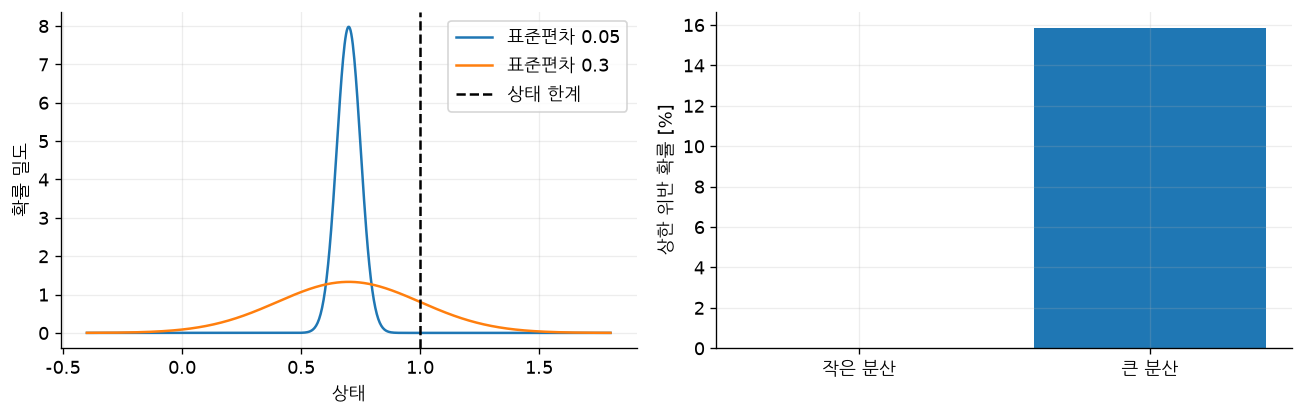

In [3]:
mu = 0.7
stds = [0.05, 0.3]
xx = np.linspace(-0.4, 1.8, 700)
fig, axs = plt.subplots(1, 2, figsize=(11, 3.6))
for sd in stds:
    axs[0].plot(xx, norm.pdf(xx, mu, sd), label=f"표준편차 {sd}")
axs[0].axvline(1, color="black", ls="--", label="상태 한계")
axs[0].set(xlabel="상태", ylabel="확률 밀도")
axs[0].legend()
risks = [norm.sf(1, mu, s) for s in stds]
axs[1].bar(["작은 분산", "큰 분산"], 100 * np.array(risks))
axs[1].set(ylabel="상한 위반 확률 [%]")
assert risks[1] > risks[0]
CHECKS["큰 분산의 상태 상한 위반 확률"] = risks[1]
CHECKS["같은 평균에서 예상 이차 비용 차이"] = stds[1] ** 2 - stds[0] ** 2
savefig(fig, "belief")


## 5.2 A Method for Output MPC — 출력 MPC의 구성 방법

**교재 인쇄 pp.341–343**

먼저 실제 상태가 추정 상태 주위의 집합 $\hat x+\Sigma$ 안에 있도록 추정기를 설계합니다. 추정 상태 자체도 측정 혁신에 의해 흔들리므로 명목 상태 주위의 또 다른 집합 $z+S$ 안에 있도록 제어합니다. 두 집합을 합한 $z+S\oplus\Sigma$가 실제 상태를 포함합니다.

두 오차는 같은 측정 잡음의 영향을 공유하므로 독립적이지 않습니다. 집합 합은 안전한 외부 경계이지만 보수적일 수 있습니다. §5.3.5에서 결합 오차계의 방향별 경계와 비교합니다.

$$
x=z+e+\epsilon,\qquad x\in z\oplus S\oplus\Sigma
$$

## 5.3 Linear Constrained Systems: Time-Invariant Case — 선형 제약 시스템: 시불변 경우

**교재 인쇄 pp.344–353**

유계 과정 외란과 측정 잡음에 대해 일정한 추정·추종 오차 집합을 사용합니다. 초기 오차가 각 불변 집합 안에 있다는 가정과, 축소한 상태·입력 집합이 비어 있지 않다는 조건을 먼저 확인합니다.

### 5.3.1 Introduction — 시불변 설계의 가정

**교재 인쇄 pp.344**

보충 모델은 a=1.1, b=0.5, c=1인 스칼라 시스템입니다. 과정 외란의 절댓값은 0.02, 측정 잡음은 0.03 이하이고 상태·입력 한계는 각각 2와 0.8입니다. 스칼라이므로 관측가능성과 제어가능성을 바로 확인할 수 있습니다. 이 범위 가정은 가우스 잡음에는 적용되지 않습니다.

### 5.3.2 State Estimator — 상태 추정기

**교재 인쇄 pp.344–346**

교재의 예측형 관측기 $\hat x^+=A\hat x+Bu+L(y-C\hat x)$를 사용합니다. 두 모델에서 같은 실제 입력을 빼면 추정 오차계는 $\epsilon^+=(A-LC)\epsilon+w-L\eta$가 됩니다.

스칼라 대칭 구간의 불변 반경은 $s_\epsilon=(\bar w+|L|\bar\eta)/(1-|a-Lc|)$입니다. 아래에서는 모든 구간 꼭짓점을 검사하고, 유계 무작위 경로를 함께 그립니다. 무작위 경로만으로 불변성을 결론짓지 않습니다.

$$
|a-Lc|s_\epsilon+\bar w+|L|\bar\eta=s_\epsilon
$$

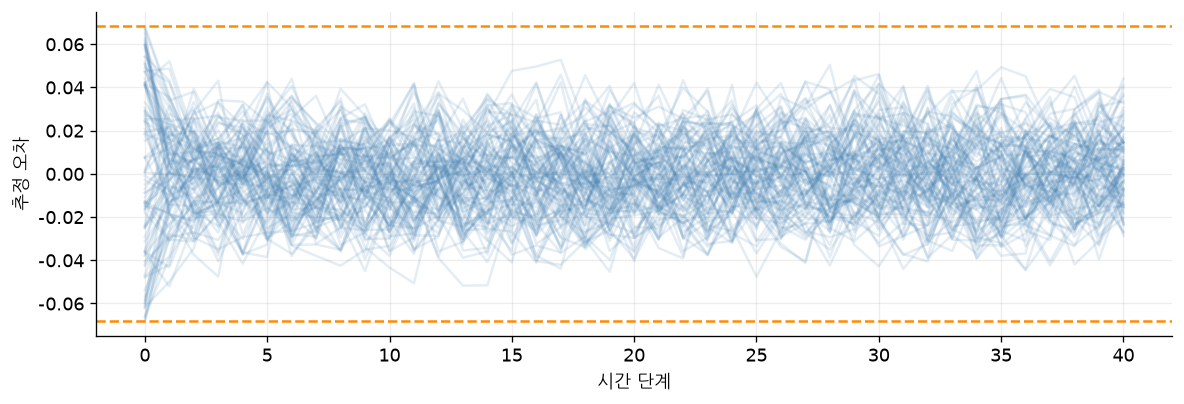

In [4]:
vertices = [
    AL * ep + w - L * v
    for ep, w, v in product([-seps, seps], [-wmax, wmax], [-vmax, vmax])
]
assert max(abs(np.array(vertices))) <= seps + 1e-12
rng = np.random.default_rng(5)
paths = np.zeros((101, 41))
paths[:, 0] = rng.uniform(-seps, seps, 101)
for k in range(40):
    paths[:, k + 1] = (
        AL * paths[:, k]
        + rng.uniform(-wmax, wmax, 101)
        - L * rng.uniform(-vmax, vmax, 101)
    )
assert np.max(abs(paths)) <= seps + 1e-12
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(paths.T, color="steelblue", alpha=0.14)
ax.axhline(seps, color="darkorange", ls="--")
ax.axhline(-seps, color="darkorange", ls="--")
ax.set(xlabel="시간 단계", ylabel="추정 오차")
CHECKS["추정 오차 불변 반경"] = seps
CHECKS["추정 오차 꼭짓점 최대 초과량"] = max(0.0, max(abs(np.array(vertices))) - seps)
savefig(fig, "observer")


### 5.3.3 Controlling the State Estimate — 추정 상태의 제어

**교재 인쇄 pp.346–348**

명목 모델은 $z^+=Az+Bv$, 실제 입력은 $u=v+K(\hat x-z)$입니다. 추종 오차에는 관측기의 혁신 $\delta=L(C\epsilon+\eta)$가 외란으로 들어옵니다.

따라서 $e^+=(A+BK)e+\delta$입니다. 스칼라에서는 $\bar\delta=|L|(|c|s_\epsilon+\bar\eta)$, $s_e=\bar\delta/(1-|a+bK|)$로 경계를 얻습니다. 상태의 총 여유는 $s_x=s_\epsilon+s_e$, 입력의 여유는 $|K|s_e$입니다. 아래는 임의의 안정한 명목 경로를 사용하는 두 겹 튜브의 보충 예이며 MPC 최적화는 다음 절에서 실행합니다.

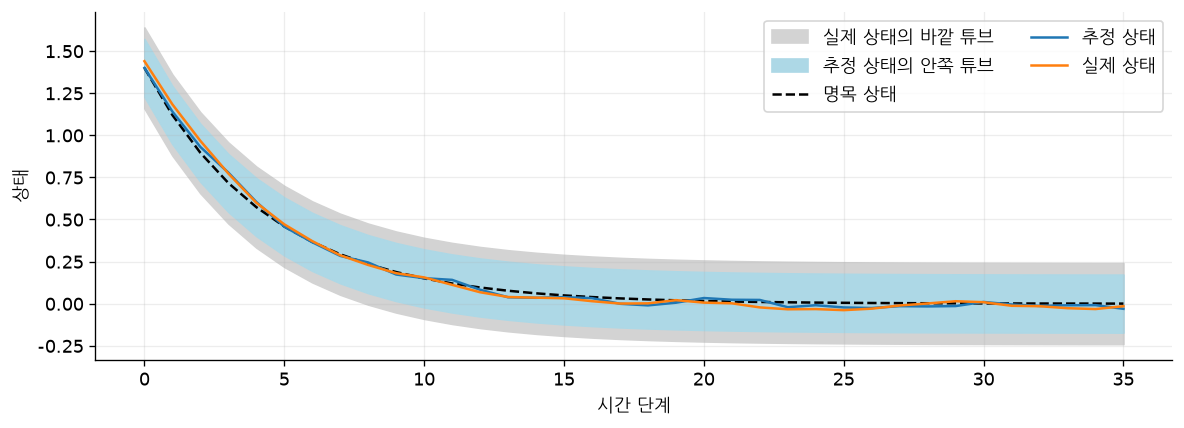

In [5]:
rng = np.random.default_rng(8)
T = 35
z = np.zeros(T + 1)
xh = z.copy()
x = z.copy()
z[0] = xh[0] = 1.4
x[0] = 1.44
for k in range(T):
    vn = (0.8 - a) * z[k] / b
    u = vn + K * (xh[k] - z[k])
    eta = rng.uniform(-vmax, vmax)
    w = rng.uniform(-wmax, wmax)
    x[k + 1] = a * x[k] + b * u + w
    xh[k + 1] = a * xh[k] + b * u + L * (c * x[k] + eta - c * xh[k])
    z[k + 1] = a * z[k] + b * vn
assert np.max(abs(x - xh)) <= seps + 1e-12 and np.max(abs(xh - z)) <= se + 1e-12
assert abs(AK) * se + delta <= se + 1e-12
fig, ax = plt.subplots(figsize=(10, 3.7))
t = np.arange(T + 1)
ax.fill_between(t, z - sx, z + sx, color="lightgray", label="실제 상태의 바깥 튜브")
ax.fill_between(t, z - se, z + se, color="lightblue", label="추정 상태의 안쪽 튜브")
ax.plot(t, z, "k--", label="명목 상태")
ax.plot(t, xh, label="추정 상태")
ax.plot(t, x, label="실제 상태")
ax.set(xlabel="시간 단계", ylabel="상태")
ax.legend(ncol=2)
CHECKS["추종 오차 불변 반경"] = se
CHECKS["총 상태 여유"] = sx
CHECKS["입력 여유"] = abs(K) * se
savefig(fig, "nested_tubes")


#### 보충 실습: 관측기 이득과 제약 여유를 함께 설계하기

§5.3.2–5.3.3의 두 반경을 연결합니다. 관측기 극점 $a-Lc$를 0에 가깝게 하면 잡음 없는 초기 오차는 빨리 사라지지만, 측정 잡음은 $L$배로 유입됩니다. 관측기만 보지 말고 $s_\epsilon$, $s_e$와 축소 입력 한계 $\bar U=U_{\max}-|K|s_e$를 함께 비교해야 합니다.

아래는 **K를 고정한 스칼라 보충 설계**입니다. 안정한 L을 골랐어도 축소 입력 집합이 비어 있을 수 있습니다. 음의 축소 반경은 사용할 수 없으므로 오른쪽 그래프에 회색으로 표시합니다. 이 실험은 모든 목적을 동시에 최적화한 관측기 설계가 아닙니다.

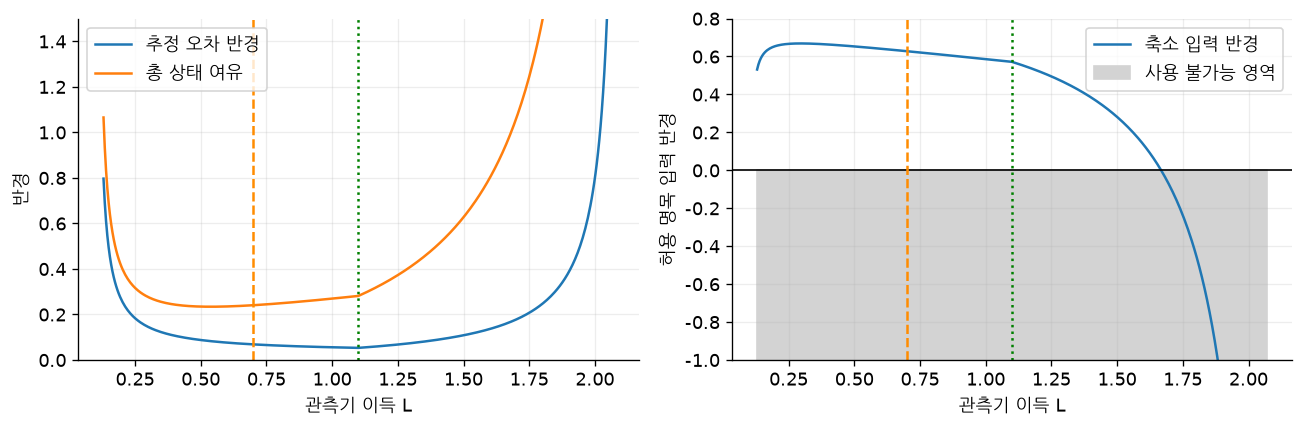

In [6]:
gains = np.linspace(0.13, 2.07, 401)
rho = np.abs(a - gains * c)
eps_radius = (wmax + gains * vmax) / (1 - rho)
e_radius = gains * (abs(c) * eps_radius + vmax) / (1 - abs(AK))
input_radius = Umax - abs(K) * e_radius
assert np.all(rho < 1) and np.any(input_radius < 0) and np.any(input_radius > 0)
fig, axs = plt.subplots(1, 2, figsize=(11, 3.7))
axs[0].plot(gains, eps_radius, label="추정 오차 반경")
axs[0].plot(gains, eps_radius + e_radius, label="총 상태 여유")
axs[0].set(xlabel="관측기 이득 L", ylabel="반경", ylim=(0, 1.5))
axs[0].legend()
axs[1].plot(gains, input_radius, label="축소 입력 반경")
axs[1].fill_between(gains, -1, 0, color="lightgray", label="사용 불가능 영역")
axs[1].axhline(0, color="black", lw=1)
axs[1].set(xlabel="관측기 이득 L", ylabel="허용 명목 입력 반경", ylim=(-1, 0.8))
axs[1].legend()
for ax in axs:
    ax.axvline(L, color="darkorange", ls="--")
    ax.axvline(a / c, color="green", ls=":")
CHECKS["안정하지만 입력 축소가 불가능한 이득 표본 수"] = np.count_nonzero(
    input_radius < 0
)
CHECKS["관측기 극점 0에서 총 상태 여유"] = (wmax + a * vmax) + a * (
    (wmax + a * vmax) + vmax
) / (1 - abs(AK))
savefig(fig, "observer_gain")


### 5.3.4 Output MPC — 출력 MPC

**교재 인쇄 pp.348–352**

명목 상태 한계를 $X\ominus\Gamma$, 입력 한계를 $U\ominus KS$로 축소합니다. 명목 중심을 매번 추정 상태로 재설정하지 않고, 이전 명목 상태와 명목 입력으로 전파합니다. 이 실습은 교재 알고리즘 5.5의 구조를 사용합니다.

이차 비용과 DARE 종단 비용, 종단 선형 피드백을 사용합니다. 종단 구간은 축소한 상태·입력 제약을 만족하고 피드백 아래 불변하도록 정합니다. 명목 MPC의 다음 해가 존재하는지, 값 함수 감소와 실제 제약 만족을 검사합니다. 잡음이 지속되면 실제 상태의 원점 수렴 대신 오차 집합으로의 접근을 해석합니다.

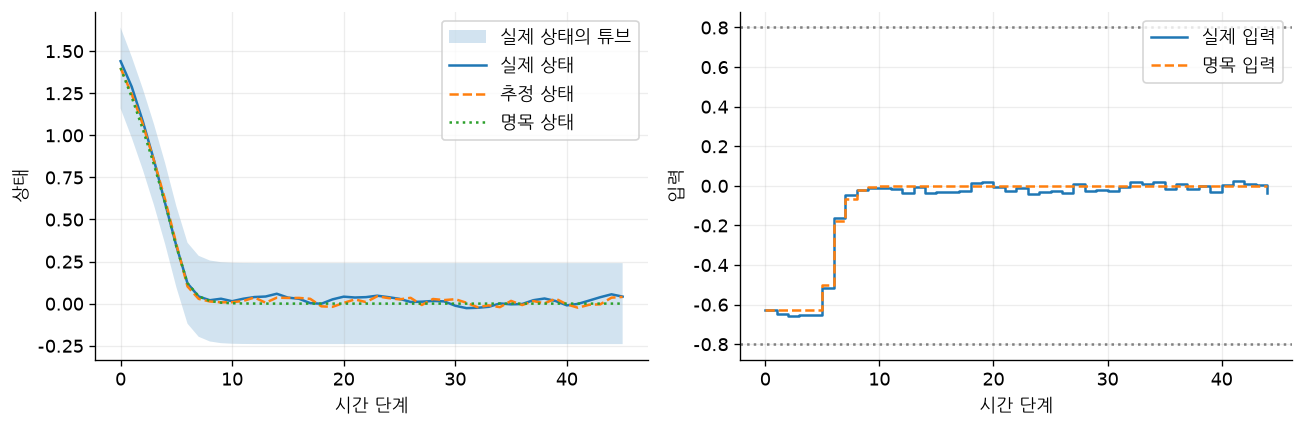

In [7]:
ctrl, P, kf, rf = qp_controller(a, b, 10, 1.0, 0.2, Ubar, Xbar, True)
assert abs(a + b * kf) < 1 and abs(kf) * rf <= Ubar and rf <= Xbar
assert abs(P - (1 + 0.2 * kf * kf + (a + b * kf) ** 2 * P)) < 1e-10
rng = np.random.default_rng(12)
T = 45
zs = [1.4]
hs = [1.4]
xs = [1.44]
us = []
vs = []
vals = []
for k in range(T):
    zz, vv, J = ctrl(zs[-1])
    vn = vv[0]
    uu = vn + K * (hs[-1] - zs[-1])
    vals.append(J)
    vs.append(vn)
    us.append(uu)
    eta = rng.uniform(-vmax, vmax)
    w = rng.uniform(-wmax, wmax)
    hs.append(a * hs[-1] + b * uu + L * (c * xs[-1] + eta - c * hs[-1]))
    xs.append(a * xs[-1] + b * uu + w)
    zs.append(a * zs[-1] + b * vn)
zs, hs, xs, us, vs, vals = map(np.array, [zs, hs, xs, us, vs, vals])
assert np.max(abs(xs - hs)) <= seps + 2e-6 and np.max(abs(hs - zs)) <= se + 2e-6
assert np.max(abs(xs)) <= Xmax + 2e-6 and np.max(abs(us)) <= Umax + 2e-6
res = np.diff(vals) + zs[:-2] ** 2 + 0.2 * vs[:-1] ** 2
assert res.max() < 2e-6
fig, axs = plt.subplots(1, 2, figsize=(11, 3.7))
t = np.arange(T + 1)
axs[0].fill_between(t, zs - sx, zs + sx, alpha=0.2, label="실제 상태의 튜브")
axs[0].plot(t, xs, label="실제 상태")
axs[0].plot(t, hs, "--", label="추정 상태")
axs[0].plot(t, zs, ":", label="명목 상태")
axs[0].set(xlabel="시간 단계", ylabel="상태")
axs[0].legend()
axs[1].step(range(T), us, where="post", label="실제 입력")
axs[1].step(range(T), vs, where="post", ls="--", label="명목 입력")
for yy in [-Umax, Umax]:
    axs[1].axhline(yy, color="gray", ls=":")
axs[1].set(xlabel="시간 단계", ylabel="입력")
axs[1].legend()
CHECKS["축소한 상태 반경"] = Xbar
CHECKS["축소한 입력 반경"] = Ubar
CHECKS["종단 구간 반경"] = rf
CHECKS["명목 비용 감소 최대 잔차"] = res.max()
CHECKS["출력 MPC 실제 입력 최대 크기"] = np.max(abs(us))
CHECKS["출력 MPC 실제 상태 최대 크기"] = np.max(abs(xs))
savefig(fig, "output_mpc")


### 5.3.5 Computing the Tightened Constraints — 축소 제약의 계산

**교재 인쇄 pp.352–353**

다차원에서는 집합 전체를 명시적으로 만들기보다 제약 방향의 최댓값, 즉 지지함수를 계산할 수 있습니다. 이 절의 보충 계산은 §5.3.4 말미의 결합 오차계도 함께 이용합니다.

$\zeta=(\epsilon,e)$이면 $\zeta^+=F\zeta+G(w,\eta)$입니다. 같은 잡음이 두 오차에 반대 부호로 들어가는 관계를 유지하면, 두 구간을 따로 합친 경계보다 작을 수 있습니다. 초기 결합 오차가 해당 결합 불변 집합에 속해야 이 작은 경계를 처음부터 적용할 수 있습니다. 아래 값은 **영 초기 오차에서의 도달 집합과 그 극한**을 분석하며 앞 절 MPC의 제약을 소급해서 바꾸지 않습니다.

무한 급수의 유한 절단값은 하한일 수 있으므로 꼬리 상한을 더해야 합니다. 행렬 거듭제곱의 블록 수축률을 사용해 남은 급수를 제한합니다.

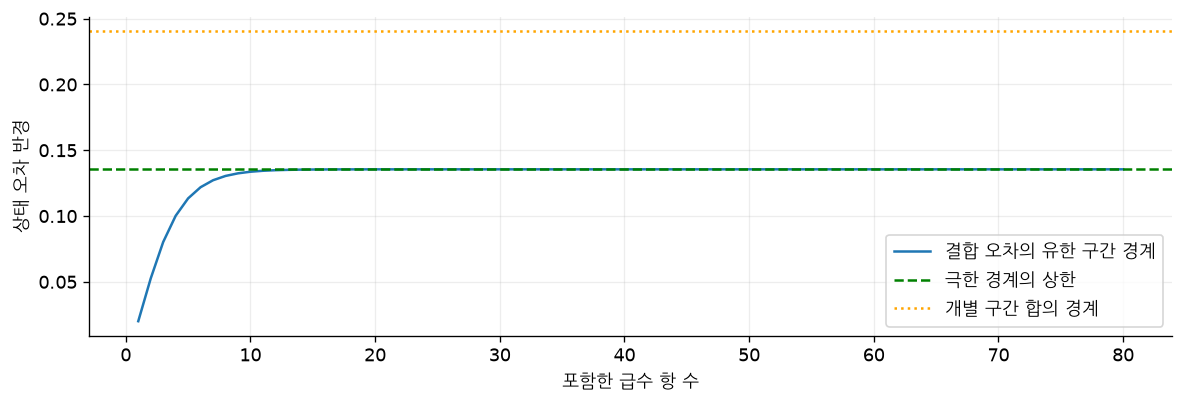

In [8]:
F = np.array([[AL, 0], [L * c, AK]])
G = np.array([[1.0, -L], [0.0, L]])
H = np.array([[1.0, 1.0]])
D = G @ np.diag([wmax, vmax])
Nsum = 80
power = np.eye(2)
terms = []
for j in range(Nsum):
    terms.append(np.abs(H @ power @ D).sum())
    power = power @ F
m = 20
theta = np.linalg.norm(np.linalg.matrix_power(F, m), np.inf)
assert theta < 1
block = sum(np.linalg.norm(np.linalg.matrix_power(F, r) @ D, np.inf) for r in range(m))
tail = np.sum(np.abs(H)) * np.linalg.norm(power, np.inf) * block / (1 - theta)
# Row-vector 1-norm times the induced infinity-norm bounds each remaining block.
partial = np.cumsum(terms)
upper = partial[-1] + tail
assert upper < sx and tail < 1e-12
# Four-step exhaustive disturbances verify the finite support sum exactly.
end = []
for seq in product(list(product([-wmax, wmax], [-vmax, vmax])), repeat=4):
    q = np.zeros(2)
    for noise in seq:
        q = F @ q + G @ noise
    end.append(float((H @ q)[0]))
assert abs(max(end) - partial[3]) < 1e-12
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(np.arange(1, Nsum + 1), partial, label="결합 오차의 유한 구간 경계")
ax.axhline(upper, color="green", ls="--", label="극한 경계의 상한")
ax.axhline(sx, color="orange", ls=":", label="개별 구간 합의 경계")
ax.set(xlabel="포함한 급수 항 수", ylabel="상태 오차 반경")
ax.legend()
CHECKS["결합 오차 방향별 경계 상한"] = upper
CHECKS["급수 꼬리 상한"] = tail
CHECKS["4단계 꼭짓점 전수 비교 오차"] = abs(max(end) - partial[3])
savefig(fig, "joint_bound")


#### 보충 실습: 두 오차의 도달 집합을 직접 그리기

$\zeta=(\epsilon,e)$ 평면에 영 초기 오차의 **12단계 도달 다각형**을 그립니다. 매 단계 $F$로 전파하고 잡음 네 꼭짓점을 더한 뒤 볼록껍질을 구하면 이 선형·구간 모델의 유한 도달 집합을 얻습니다. 샘플 경로의 산점도가 아닙니다.

개별 불변 구간의 직사각형에는 두 오차가 동시에 최댓값인 모서리가 들어갑니다. 그러나 공유 잡음의 부호 관계 때문에 결합 도달 집합에는 그 모서리가 들어가지 않습니다. 직선 $e+\epsilon=\gamma$는 실제 상태 오차 방향의 지지선입니다. **12단계 다각형 자체를 무한 시간 불변 집합이라고 부르지 않습니다.** 앞의 80항+꼬리 경계를 함께 비교합니다.

초기값 $(s_\epsilon,s_e)$는 두 개별 구간의 가정을 만족하지만 작은 결합 경계를 위반합니다. 따라서 작은 경계로 제약을 교체하려면 초기 결합 집합도 다시 확인해야 합니다.

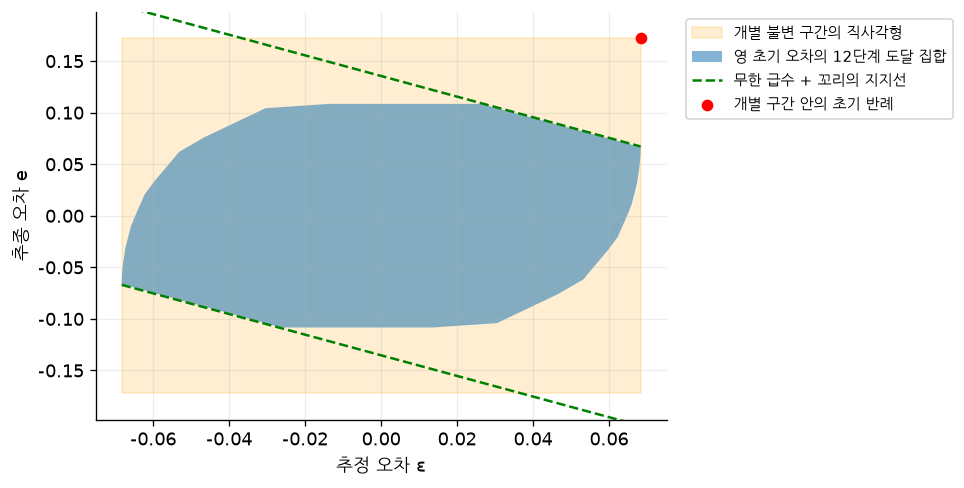

In [9]:
from scipy.spatial import ConvexHull

poly = np.zeros((1, 2))
noise_vertices = np.array(list(product([-1.0, 1.0], repeat=2))) @ D.T
for _ in range(12):
    candidates = (poly @ F.T)[:, None, :] + noise_vertices[None, :, :]
    candidates = candidates.reshape(-1, 2)
    poly = candidates[ConvexHull(candidates).vertices]
finite_support = np.max(poly.sum(axis=1))
assert abs(finite_support - partial[11]) < 1e-12
assert np.max(abs(poly[:, 0])) <= seps + 1e-12 and np.max(abs(poly[:, 1])) <= se + 1e-12
fig, ax = plt.subplots(figsize=(8.2, 4.2))
ax.fill(
    [-seps, seps, seps, -seps],
    [-se, -se, se, se],
    alpha=0.18,
    color="orange",
    label="개별 불변 구간의 직사각형",
)
ax.fill(poly[:, 0], poly[:, 1], alpha=0.55, label="영 초기 오차의 12단계 도달 집합")
grid = np.linspace(-seps, seps, 100)
for sign in [-1, 1]:
    ax.plot(
        grid,
        sign * upper - grid,
        "g--",
        label="무한 급수 + 꼬리의 지지선" if sign == 1 else None,
    )
ax.scatter([seps], [se], c="red", zorder=4, label="개별 구간 안의 초기 반례")
ax.set(xlabel="추정 오차 ε", ylabel="추종 오차 e", ylim=(-se * 1.15, se * 1.15))
ax.legend(fontsize=9, loc="upper left", bbox_to_anchor=(1.02, 1))
CHECKS["12단계 다각형과 지지함수 비교 오차"] = abs(finite_support - partial[11])
CHECKS["개별 구간 초기값의 결합 경계 초과량"] = sx - upper
savefig(fig, "joint_geometry")


## 5.4 Linear Constrained Systems: Time-Varying Case — 선형 제약 시스템: 시변 경우

**교재 인쇄 pp.353**

여기서 시변 경우는 주로 시간에 따라 달라지는 오차 집합과 축소 제약을 뜻합니다. 명목 중심과 추정 상태가 같게 시작하면 추종 오차 집합은 0에서 커질 수 있고, 초기 추정 불확실성이 크면 추정 오차 집합은 줄어들 수 있습니다.

보충 예는 $s_{\epsilon,k+1}=|a-Lc|s_{\epsilon,k}+\bar w+|L|\bar\eta$와 $s_{e,k+1}=|a+bK|s_{e,k}+|L|(|c|s_{\epsilon,k}+\bar\eta)$를 전파합니다. 서로 다른 초기 정보에 따른 전체 상태 여유를 비교합니다. 시변 집합을 사용한 온라인 MPC 전체를 구현한 예는 아닙니다.

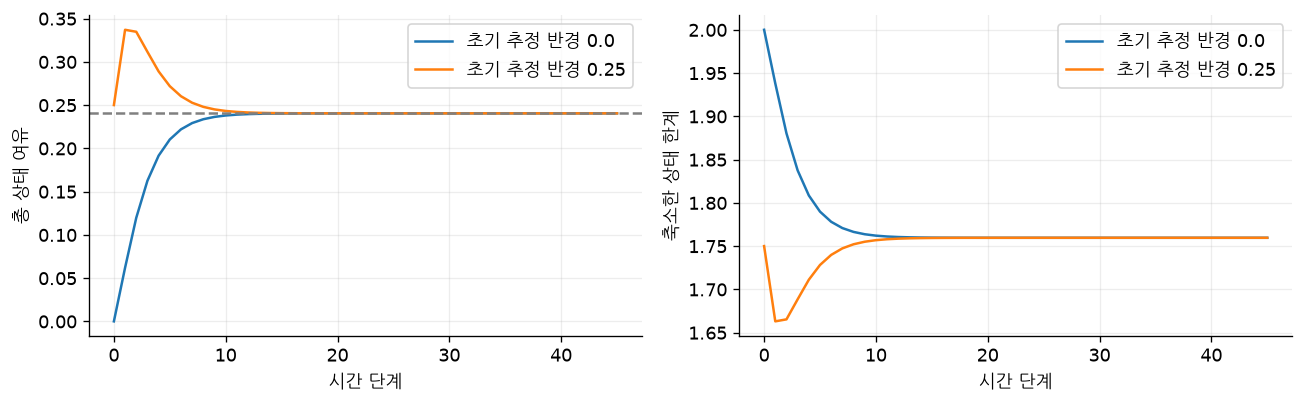

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(11, 3.5))
ends = []
for ep0 in [0.0, 0.25]:
    ep, ee = [ep0], [0.0]
    for k in range(45):
        ee.append(abs(AK) * ee[-1] + abs(L) * (abs(c) * ep[-1] + vmax))
        ep.append(abs(AL) * ep[-1] + wmax + abs(L) * vmax)
    rr = np.array(ep) + np.array(ee)
    ends.append(rr[-1])
    axs[0].plot(rr, label=f"초기 추정 반경 {ep0}")
    axs[1].plot(Xmax - rr, label=f"초기 추정 반경 {ep0}")
assert max(abs(np.array(ends) - sx)) < 1e-8
axs[0].axhline(sx, color="gray", ls="--")
axs[0].set(xlabel="시간 단계", ylabel="총 상태 여유")
axs[1].set(xlabel="시간 단계", ylabel="축소한 상태 한계")
axs[0].legend()
axs[1].legend()
CHECKS["시변 반경의 정상상태 최대 차이"] = max(abs(np.array(ends) - sx))
savefig(fig, "varying_sets")


## 5.5 Offset-Free MPC — 정상상태 오차 없는 MPC

**교재 인쇄 pp.353–355**

모델에 없는 일정한 외란이 있으면 기존 목표와 예측 모델로는 출력이 설정값에 도달하지 못할 수 있습니다. 외란을 적분 상태 $d^+=d+w_d$로 추가하여 추정하고, 그 추정값으로 정상상태 목표 상태·입력을 다시 구합니다.

적분 외란 모델은 추정에 유용하지만 무한 시간에 걸쳐 외란이 유계임을 보장하지 않습니다. 교재는 실제 외란이 유계라는 추가 조건을 둡니다. 아래 오프셋 실습은 잡음 없는 상수 외란으로 원리를 확인하고, 이후 변동 외란의 잔여 오차와 목표 실행 가능성을 별도로 살펴봅니다.

### 5.5.1 Estimation — 확장 상태의 추정

**교재 인쇄 pp.355–356**

상태와 외란을 묶은 $\xi=(x,d)$의 확장 관측기를 구성합니다. 원래 모델이 관측가능하다는 사실만으로 확장 모델이 검출가능한 것은 아닙니다. 특히 추가된 단위원 고유값을 측정에서 구분할 수 있어야 합니다.

보충 모델은 $a=0.8,b=0.5,B_d=1,C=1,C_d=0$으로 상수 과정 외란을 추정합니다. 관측기 극점은 0.35와 0.45로 배치합니다. 반례로 $A=1,B_d=0,C=1,C_d=1$이면 상태와 측정 바이어스를 따로 구분할 수 없고 확장 계의 단위원 모드가 관측 불가능합니다.

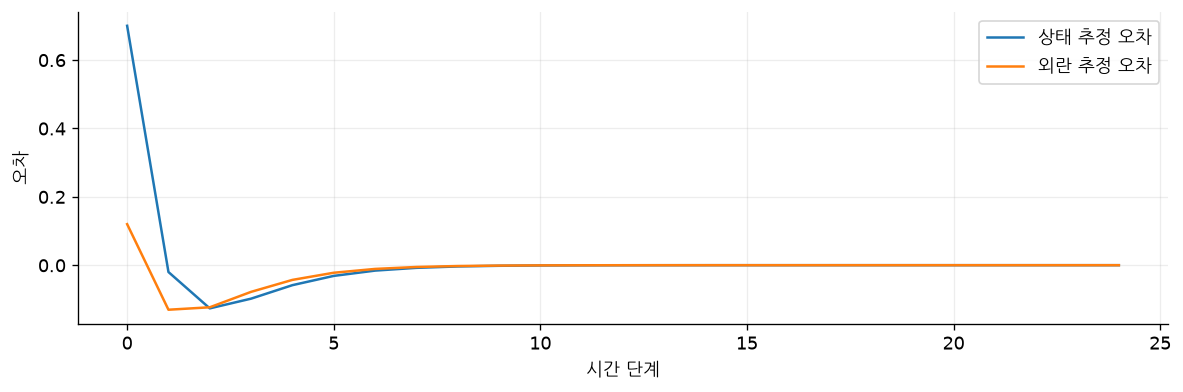

In [11]:
ao, bo = 0.8, 0.5
Ae = np.array([[ao, 1.0], [0.0, 1.0]])
Be = np.array([bo, 0.0])
Ce = np.array([[1.0, 0.0]])
Le = place_poles(Ae.T, Ce.T, [0.35, 0.45]).gain_matrix.T
assert np.linalg.matrix_rank(np.vstack([Ce, Ce @ Ae])) == 2
bad = np.array([[0.0, 0.0], [1.0, 1.0]])
assert np.linalg.matrix_rank(bad) == 1
err = [np.array([0.7, 0.12])]
for k in range(24):
    err.append((Ae - Le @ Ce) @ err[-1])
err = np.array(err)
assert np.linalg.norm(err[-1]) < 1e-7
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.plot(err[:, 0], label="상태 추정 오차")
ax.plot(err[:, 1], label="외란 추정 오차")
ax.set(xlabel="시간 단계", ylabel="오차")
ax.legend()
CHECKS["확장 관측기 스펙트럴 반지름"] = max(abs(np.linalg.eigvals(Ae - Le @ Ce)))
CHECKS["확장 관측기의 마지막 오차 크기"] = np.linalg.norm(err[-1])
CHECKS["나쁜 외란 모델의 단위원 조건 행렬 계수"] = np.linalg.matrix_rank(bad)
savefig(fig, "augmented_observer")


#### 보충 실습: 측정이 같으면 두 상태를 구별할 수 없다

§5.5.1은 확장 모델의 검출가능성을 Lemma 1.8과 연결합니다. 원래 $(A,C)$가 검출가능할 때 추가된 단위원 모드를 확인하는 행렬은
$$M_1=\begin{bmatrix}I-A&-B_d\\ C&C_d\end{bmatrix}.$$
이 행렬의 **열 계수가 $n+p$**여야 하므로 외란 상태 수 $p$는 측정 수를 초과할 수 없습니다. 다른 불안정 모드도 원래 모델에서 검출가능해야 합니다.

반례 $A=1,B_d=0,C=C_d=1$에서 $(x,d)=(0,1)$과 $(1,0)$은 어떤 동일 입력에도 동일한 출력 $y=x+d$를 만듭니다. 극점 배치나 더 긴 측정 기록으로 이 모호성을 해결할 수 없습니다. 비교 모델 $A=0.8,B_d=1,C=1,C_d=0$에서는 두 초기값의 출력이 다르며 계수도 2입니다. 숫자는 직접 정한 보충 예입니다.

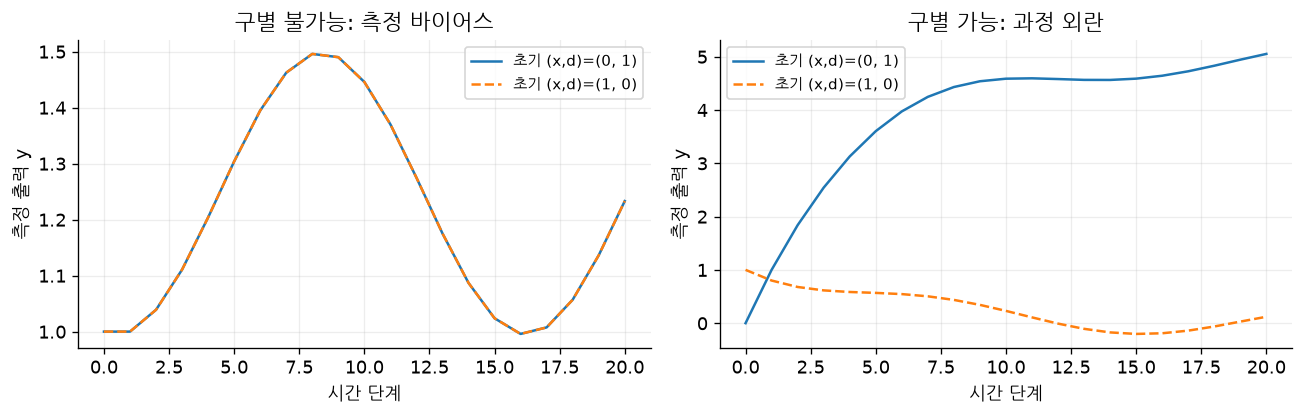

In [12]:
initials = [np.array([0.0, 1.0]), np.array([1.0, 0.0])]
models = [
    ("구별 불가능: 측정 바이어스", np.eye(2), np.array([1.0, 1.0])),
    ("구별 가능: 과정 외란", Ae, Ce[0]),
]
fig, axs = plt.subplots(1, 2, figsize=(11, 3.6))
differences = []
ranks = []
for ax, (name, aa, cc) in zip(axs, models):
    outputs = []
    for j, q0 in enumerate(initials):
        q = q0.copy()
        yy = []
        for k in range(21):
            yy.append(cc @ q)
            q = aa @ q + np.array([0.5, 0.0]) * (0.2 * np.sin(0.4 * k))
        outputs.append(np.array(yy))
        ax.plot(
            yy, "-" if j == 0 else "--", label=f"초기 (x,d)={tuple(map(int, q0))}"
        )
    m1 = np.vstack([np.eye(2) - aa, cc])
    ranks.append(np.linalg.matrix_rank(m1))
    differences.append(np.max(abs(outputs[0] - outputs[1])))
    ax.set(title=name, xlabel="시간 단계", ylabel="측정 출력 y")
    ax.legend(fontsize=9)
assert ranks == [1, 2] and differences[0] < 1e-12 and differences[1] > 1
CHECKS["식별 불가능 모델의 출력 경로 차이"] = differences[0]
CHECKS["식별 가능한 모델의 단위원 조건 계수"] = ranks[1]
savefig(fig, "detectability")


### 5.5.2 Control — 목표값 계산과 제어

**교재 인쇄 pp.356–360**

외란 추정 상태 자체는 입력으로 안정화할 수 없으므로, 외란을 0으로 보내는 LQR 문제로 만들지 않습니다. 현재 외란 추정값을 고정한 예측 모델에서 정상상태 목표를 구하고 그 목표로 상태를 조절합니다.

스칼라 보충 예의 목표는 $x_s=r$, $u_s=((1-a)r-\hat d)/b$입니다. 비용은 $(z-x_s)^2+R(v-u_s)^2$로 구성합니다. 일반적인 목표 계산에서는 평형 등식, 제어 출력 등식, 상태·입력 제약을 함께 만족해야 합니다.

여기서는 오프셋 제거를 분리해 확인하려고 **관측기 기반 명목 MPC**를 사용합니다. §5.3의 두 겹 강인 튜브나 교재 알고리즘 5.7 전체를 구현한 것은 아닙니다. 같은 실제 상수 외란 아래 기본 관측기 MPC와 확장 관측기 MPC를 비교합니다.

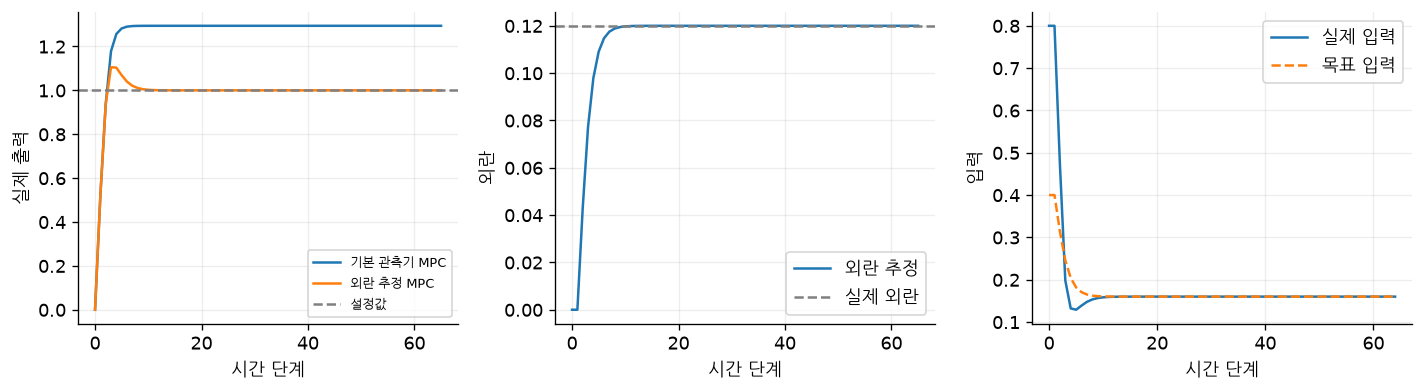

In [13]:
track, Pt, kt, _ = qp_controller(ao, bo, 10, 1.0, 0.2, 0.8)


def run_tracking(ds, augmented=True, r=1.0):
    xp = [0.0]
    est = np.zeros(2)
    estimates = [est.copy()]
    inputs = []
    targets = []
    for d in ds:
        dh = est[1] if augmented else 0.0
        us = ((1 - ao) * r - dh) / bo
        assert abs(us) <= 0.8 + 1e-8, "정상상태 목표 입력이 실행 불가능합니다."
        zz, vv, _ = track(est[0], dh, r)
        u = vv[0]
        y = xp[-1]
        if augmented:
            est = Ae @ est + Be * u + Le[:, 0] * (y - float((Ce @ est)[0]))
        else:
            est = np.array([ao * est[0] + bo * u + 0.5 * (y - est[0]), 0.0])
        xp.append(ao * xp[-1] + bo * u + d)
        inputs.append(u)
        targets.append(us)
        estimates.append(est.copy())
    return np.array(xp), np.array(estimates), np.array(inputs), np.array(targets)


ds = np.full(65, 0.12)
base = run_tracking(ds, False)
off = run_tracking(ds, True)
assert abs(off[0][-1] - 1) < 1e-6 and abs(off[1][-1, 1] - 0.12) < 1e-8
assert abs(base[0][-1] - 1) > 0.02
assert abs((1 - ao) * 1 - bo * ((1 - ao - 0.12) / bo) - 0.12) < 1e-12
fig, axs = plt.subplots(1, 3, figsize=(12, 3.4))
axs[0].plot(base[0], label="기본 관측기 MPC")
axs[0].plot(off[0], label="외란 추정 MPC")
axs[0].axhline(1, color="gray", ls="--", label="설정값")
axs[0].set(xlabel="시간 단계", ylabel="실제 출력")
axs[0].legend(fontsize=8)
axs[1].plot(off[1][:, 1], label="외란 추정")
axs[1].axhline(0.12, color="gray", ls="--", label="실제 외란")
axs[1].set(xlabel="시간 단계", ylabel="외란")
axs[1].legend()
axs[2].plot(off[2], label="실제 입력")
axs[2].plot(off[3], "--", label="목표 입력")
axs[2].set(xlabel="시간 단계", ylabel="입력")
axs[2].legend()
CHECKS["기본 MPC의 마지막 출력 오프셋"] = base[0][-1] - 1
CHECKS["외란 추정 MPC의 마지막 출력 오프셋"] = off[0][-1] - 1
CHECKS["외란 추정 최종 오차"] = abs(off[1][-1, 1] - 0.12)
CHECKS["외란 보정 후 목표 입력"] = (1 - ao - 0.12) / bo
savefig(fig, "offset_free")


#### 보충 실습: 목표 평형의 실행 가능 영역

§5.5.2 인쇄 p.358의 목표 계산은 평형·출력 등식뿐 아니라 제약도 만족해야 합니다. $a=0.8,b=0.5,|u_s|\le0.8,|x_s|\le2$를 사용하면
$$x_s=r,\quad u_s=\frac{0.2r-\hat d}{0.5},\quad |0.2r-\hat d|\le0.4.$$
등식 계수 행렬의 계수가 충분해도 부등식 제약 때문에 목표가 불가능할 수 있습니다. $(r,\hat d)$ 평면의 녹색 띠로 그 차이를 확인합니다.

두 번째 그림은 **보충 목표 조정 규칙**입니다. 요청값 1을 가능한 출력 구간에 투영합니다. 외란 0.8이면 가장 가까운 목표는 2, 입력은 −0.8입니다. 경계에 있으므로 추가 외란을 위한 여유는 없습니다. 이 정적 목표 조정은 과도 상태의 제약이나 재귀적 실행 가능성을 보장하는 reference governor 전체 구현이 아닙니다.

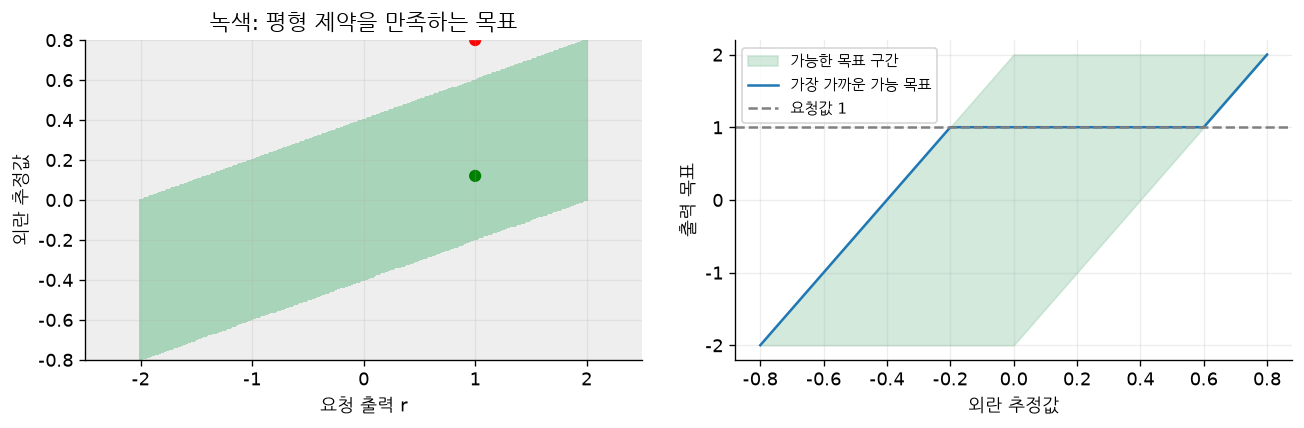

In [14]:
dgrid = np.linspace(-0.8, 0.8, 201)
rgrid = np.linspace(-2.5, 2.5, 251)
rr, dd = np.meshgrid(rgrid, dgrid)
mask = (abs(0.2 * rr - dd) <= 0.4) & (abs(rr) <= 2)
low = np.maximum(-2, (dgrid - 0.4) / 0.2)
high = np.minimum(2, (dgrid + 0.4) / 0.2)
assert np.all(low <= high + 1e-12)
adjusted = np.clip(1.0, low, high)
ustar = (0.2 * adjusted - dgrid) / 0.5
assert np.max(abs(ustar)) <= 0.8 + 1e-12 and np.max(abs(adjusted)) <= 2 + 1e-12
fig, axs = plt.subplots(1, 2, figsize=(11, 3.7))
axs[0].contourf(
    rr, dd, mask.astype(float), levels=[-0.5, 0.5, 1.5], colors=["#eeeeee", "#a8d5ba"]
)
axs[0].scatter([1, 1], [0.12, 0.8], c=["green", "red"], s=40)
axs[0].set(
    xlabel="요청 출력 r",
    ylabel="외란 추정값",
    title="녹색: 평형 제약을 만족하는 목표",
)
axs[1].fill_between(
    dgrid, low, high, color="#a8d5ba", alpha=0.5, label="가능한 목표 구간"
)
axs[1].plot(dgrid, adjusted, label="가장 가까운 가능 목표")
axs[1].axhline(1, color="gray", ls="--", label="요청값 1")
axs[1].set(xlabel="외란 추정값", ylabel="출력 목표")
axs[1].legend(fontsize=9)
CHECKS["외란 0.8에서 조정된 목표"] = adjusted[-1]
CHECKS["목표 조정 후 최대 입력 크기"] = np.max(abs(ustar))
savefig(fig, "target_feasibility")


#### 보충 실습: 입력 비용도 목표 입력을 기준으로 잡기

인쇄 p.359의 단계 비용은 상태뿐 아니라 **입력도 목표와의 차이**로 계산합니다. 이를 빠뜨리는 영향을 보기 위해 외란과 상태를 정확히 알고 있는 한 단계 MPC를 비교합니다. 추정 오차의 영향을 제거하고 $q=1,R=2,a=0.8,b=0.5,d=0.12,r=1$을 고정합니다.
$$J=q(x^+-r)^2+R(u-u_{\mathrm{ref}})^2,\qquad u^*=\frac{qb(r-ax-d)+R u_{\mathrm{ref}}}{qb^2+R}.$$
$u_{\mathrm{ref}}=u_s=0.16$이면 $x=r$에서 입력도 $u_s$가 되어 평형입니다. 반면 $u_{\mathrm{ref}}=0$이면 목표 유지에 필요한 입력까지 벌점으로 주므로 정상상태가 달라집니다. 이 짧은 구간 비용은 교재의 전체 종단 설계를 재현하는 것이 아니라 비용 중심의 역할을 분리한 보충 실험입니다.

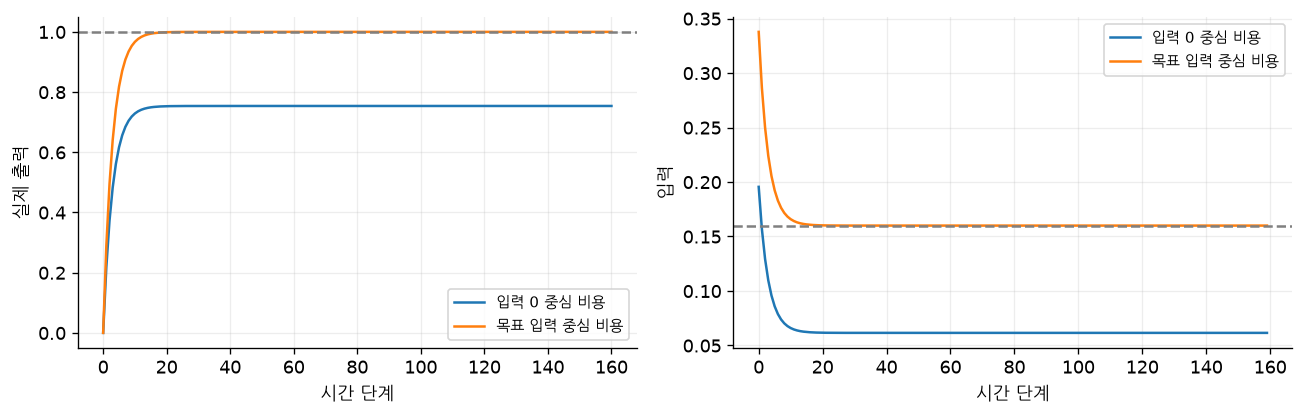

In [15]:
qa, ra, aa, bb, dd, rr = 1.0, 2.0, 0.8, 0.5, 0.12, 1.0
us_eq = ((1 - aa) * rr - dd) / bb
den = qa * bb**2 + ra
closed_pole = aa * ra / den
fig, axs = plt.subplots(1, 2, figsize=(11, 3.6))
equilibria = []
for uref, label in [(0.0, "입력 0 중심 비용"), (us_eq, "목표 입력 중심 비용")]:
    xx = [0.0]
    uu = []
    for _ in range(160):
        control = (qa * bb * (rr - aa * xx[-1] - dd) + ra * uref) / den
        assert abs(control) <= 0.8
        uu.append(control)
        xx.append(aa * xx[-1] + bb * control + dd)
    equilibrium = (bb * (qa * bb * (rr - dd) + ra * uref) / den + dd) / (
        1 - closed_pole
    )
    assert abs(xx[-1] - equilibrium) < 1e-10
    equilibria.append(equilibrium)
    axs[0].plot(xx, label=label)
    axs[1].plot(uu, label=label)
axs[0].axhline(rr, color="gray", ls="--")
axs[1].axhline(us_eq, color="gray", ls="--")
axs[0].set(xlabel="시간 단계", ylabel="실제 출력")
axs[1].set(xlabel="시간 단계", ylabel="입력")
for ax in axs:
    ax.legend(fontsize=9)
assert abs(equilibria[1] - rr) < 1e-12 and abs(equilibria[0] - rr) > 0.1
CHECKS["입력 0 중심 비용의 정상상태 오프셋"] = equilibria[0] - rr
CHECKS["목표 입력 중심 비용의 정상상태 오프셋"] = equilibria[1] - rr
savefig(fig, "input_cost_center")


### 5.5.3 Convergence Analysis — 수렴 분석

**교재 인쇄 pp.360–363**

외란 추정이 고정된 경우의 값 함수 감소식에 다음 외란 추정값을 그냥 대입할 수 없습니다. 목표와 예측 모델이 바뀌는 효과를 추가해야 합니다. 교재는 추정 변화가 충분히 작고 목표 사상이 연속이며 실행 가능성이 유지되는 등의 조건 아래 추적 오차의 범위를 논의합니다.

아래는 느리게·빠르게 변하는 외란의 보충 비교입니다. 주어진 두 경로의 잔여 오차를 비교하며 일반적인 속도 임계값을 증명하지 않습니다. 목표 입력 한계 검사도 별도로 수행합니다. 정상상태 목표가 가능하다는 사실만으로 유한 구간 MPC의 재귀적 실행 가능성이 보장되지는 않습니다.

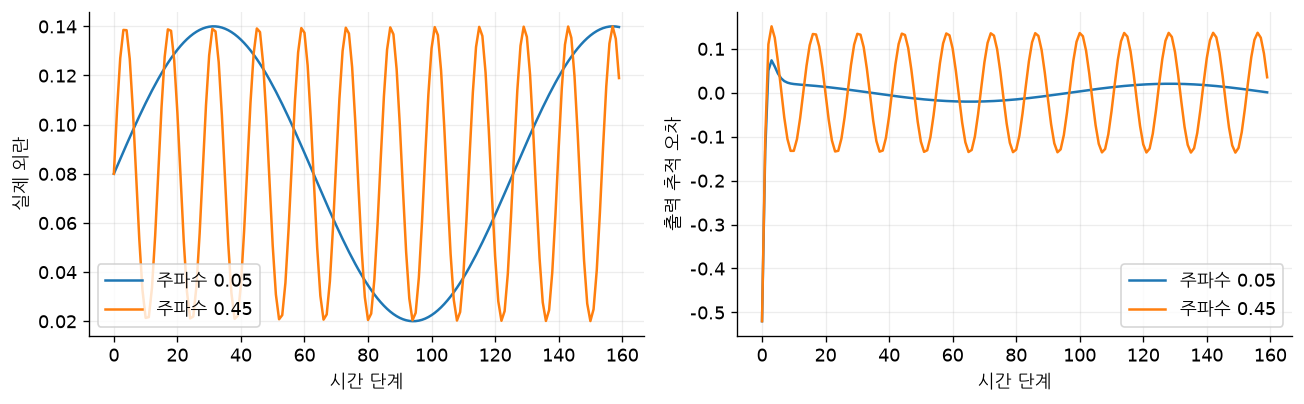

In [16]:
t = np.arange(160)
results = []
fig, axs = plt.subplots(1, 2, figsize=(11, 3.5))
for freq in [0.05, 0.45]:
    d = 0.08 + 0.06 * np.sin(freq * t)
    out = run_tracking(d)
    rmse = np.sqrt(np.mean((out[0][-80:] - 1) ** 2))
    results.append(rmse)
    axs[0].plot(t, d, label=f"주파수 {freq}")
    axs[1].plot(t, out[0][1:] - 1, label=f"주파수 {freq}")
    CHECKS[f"변동 외란 {freq} 추적 RMSE"] = rmse
axs[0].set(xlabel="시간 단계", ylabel="실제 외란")
axs[1].set(xlabel="시간 단계", ylabel="출력 추적 오차")
axs[0].legend()
axs[1].legend()
assert all(np.isfinite(results))
# Target equilibrium feasibility: x_s=1, u_s=(0.2-d_hat)/0.5.
feasible_d = 0.12
impossible_d = 0.8
assert abs((0.2 - feasible_d) / 0.5) <= 0.8 and abs((0.2 - impossible_d) / 0.5) > 0.8
CHECKS["실행 불가능 목표의 입력 한계 초과량"] = abs((0.2 - impossible_d) / 0.5) - 0.8
savefig(fig, "drifting_target")


## 5.6 Nonlinear Constrained Systems — 비선형 제약 시스템

**교재 인쇄 pp.363**

교재는 비선형 시스템에서 MHE를 사용할 수 있지만, 추정기와 제어기를 결합한 안정성은 별도 문제라고 짧게 논의합니다. 이 내용은 **2017년 판의 설명**이며 현재 연구 현황을 주장하는 문장이 아닙니다.

보충 예는 $f(x)=0.8x+0.1\tanh x$인 비선형 관측 오차를 분석합니다. $0.8\le f'(x)\le0.9$이고 $L=0.6$이면 평균값 정리에 의해 $|f(x)-f(\hat x)-L(x-\hat x)|\le0.3|x-\hat x|$입니다. 따라서 유계 잡음에서 추정 오차의 전역 구간 경계를 얻습니다. 이는 **관측 오차의 경계**이며 비선형 MPC 전체의 안정성·제약 만족을 증명하지 않습니다.

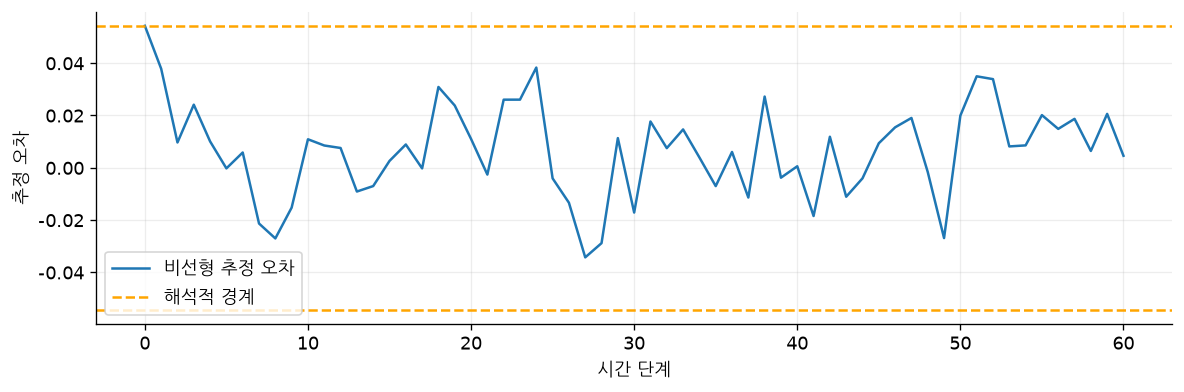

In [17]:
ln = 0.6
sn = (wmax + ln * vmax) / (1 - 0.3)
rng = np.random.default_rng(51)
xx, hh = 1.0, 1.0 - sn
errors = [xx - hh]
fn = lambda z: 0.8 * z + 0.1 * np.tanh(z)
for k in range(60):
    u = 0.2 * np.sin(0.3 * k)
    w = rng.uniform(-wmax, wmax)
    eta = rng.uniform(-vmax, vmax)
    xn = fn(xx) + 0.5 * u + w
    hn = fn(hh) + 0.5 * u + ln * (xx + eta - hh)
    assert abs(xn - hn) <= 0.3 * abs(xx - hh) + wmax + ln * vmax + 1e-12
    xx, hh = xn, hn
    errors.append(xx - hh)
assert max(abs(np.array(errors))) <= sn + 1e-12
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.plot(errors, label="非선형 추정 오차".replace("非", "비"))
ax.axhline(sn, color="orange", ls="--", label="해석적 경계")
ax.axhline(-sn, color="orange", ls="--")
ax.set(xlabel="시간 단계", ylabel="추정 오차")
ax.legend()
CHECKS["비선형 관측 오차 불변 반경"] = sn
CHECKS["비선형 관측 오차 최대 초과량"] = max(0.0, max(abs(np.array(errors))) - sn)
savefig(fig, "nonlinear_bound")


## 5.7 Notes — 문헌 해설

**교재 인쇄 pp.363–365**

교재는 분리 원리, 출력 튜브 MPC, 비선형 MHE·MPC 결합과 변동 목표 추적 문헌을 연결합니다. 선형 강인 제어에는 외란 집합·초기 오차·종단 조건이, 오프셋 제거에는 외란 검출가능성과 목표 실행 가능성이 추가됩니다. 문헌의 주장과 실습에서 실제 확인한 조건을 구분해 읽습니다.

## 5.8 Exercises — 연습문제

**교재 인쇄 pp.366**

교재 연습문제 5.1–5.6은 집합 거리·합·선형 변환, 5.7은 볼록 집합의 가중 합, 5.8은 안정한 집합 재귀의 수렴을 다룹니다. 보충 실습에서는 1차원 구간의 하우스도르프 거리와 이동·축소 관계를 계산합니다. 구간 검사는 일반 차원의 정리를 증명하는 것과 구분합니다.

In [18]:
haus = lambda A, B: float(np.max(abs(np.array(A) - np.array(B))))
Aint = np.array([-1.0, 2.0])
shift = 0.7
assert abs(haus(Aint + shift, Aint) - abs(shift)) < 1e-12
assert (
    abs(haus(0.4 * Aint, 0.4 * (Aint + shift)) - 0.4 * haus(Aint, Aint + shift)) < 1e-12
)
CHECKS["구간 평행 이동의 하우스도르프 거리"] = haus(Aint + shift, Aint)
print("구간 이동·축소 관계 확인 완료")


구간 이동·축소 관계 확인 완료


## 보충 과제와 힌트

1. 측정 잡음 경계를 두 배로 하면 추정 반경·추종 반경·축소 제약이 각각 어떻게 달라지나요?
2. $L$을 키우면 관측 오차계는 빨라질 수 있지만 잡음 영향은 어떻게 바뀌나요? 안정 조건부터 검사하세요.
3. 명목 중심을 매 시점 추정 상태로 재설정하면 현재 구현의 값 함수 감소 검사를 그대로 사용할 수 있나요?
4. 결합 오차 경계를 처음부터 적용하려면 초기 오차의 어떤 관계를 확인해야 하나요?
5. 외란을 추정해도 목표 입력이 허용 범위를 넘으면 오프셋 0을 요구할 수 있나요?
6. 비선형 관측기의 전역 오차 경계가 있어도 MPC 종단 조건과 실행 가능성이 필요한 이유를 설명하세요.

<details><summary>힌트</summary>

1. $s_\epsilon$, $\bar\delta$, $s_e$를 순서대로 다시 계산하세요. 상태에는 두 반경, 입력에는 $|K|s_e$가 들어갑니다.
2. $|a-Lc|$뿐 아니라 $|L|\bar\eta$도 함께 보세요.
3. 명목 동역학과 이전 해의 이동 후보가 달라집니다. 기존 증명과 검사식을 그대로 재사용할 수 없습니다.
4. 각 성분이 개별 구간에 속하는 것과 결합 불변 집합에 속하는 것은 다릅니다.
5. 정상상태 평형과 입력 제약을 함께 만족하는 목표가 있어야 합니다. 목표 조정 등 별도 설계가 필요합니다.
6. 관측 오차를 제한하는 성질은 제어 최적화 문제의 해 존재나 제어 후 제약 만족을 자동으로 보장하지 않습니다.

</details>

## 실행 검증 결과

분포·불변 구간·꼭짓점·명목 비용 감소·목표 오프셋·비선형 관측 경계를 각각 검증합니다.

In [19]:
for name, value in CHECKS.items():
    print(f"{name}: {value:.8g}")
print("검증 지표 수:", len(CHECKS))
print(
    {
        "Python": sys.version.split()[0],
        "NumPy": np.__version__,
        "SciPy": scipy.__version__,
        "Matplotlib": matplotlib.__version__,
        "CVXPY": cp.__version__,
    }
)


큰 분산의 상태 상한 위반 확률: 0.15865525
같은 평균에서 예상 이차 비용 차이: 0.0875
추정 오차 불변 반경: 0.068333333
추정 오차 꼭짓점 최대 초과량: 0
추종 오차 불변 반경: 0.17208333
총 상태 여유: 0.24041667
입력 여유: 0.17208333
안정하지만 입력 축소가 불가능한 이득 표본 수: 83
관측기 극점 0에서 총 상태 여유: 0.28125
축소한 상태 반경: 1.7595833
축소한 입력 반경: 0.62791667
종단 구간 반경: 0.33889284
명목 비용 감소 최대 잔차: 5.5321654e-08
출력 MPC 실제 입력 최대 크기: 0.65642375
출력 MPC 실제 상태 최대 크기: 1.44
결합 오차 방향별 경계 상한: 0.13541667
급수 꼬리 상한: 2.0809169e-18
4단계 꼭짓점 전수 비교 오차: 0
12단계 다각형과 지지함수 비교 오차: 0
개별 구간 초기값의 결합 경계 초과량: 0.105
시변 반경의 정상상태 최대 차이: 4.8204829e-11
확장 관측기 스펙트럴 반지름: 0.45
확장 관측기의 마지막 오차 크기: 1.4983462e-08
나쁜 외란 모델의 단위원 조건 행렬 계수: 1
식별 불가능 모델의 출력 경로 차이: 2.220446e-16
식별 가능한 모델의 단위원 조건 계수: 2
기본 MPC의 마지막 출력 오프셋: 0.2942418
외란 추정 MPC의 마지막 출력 오프셋: 1.2878587e-14
외란 추정 최종 오차: 5.5511151e-17
외란 보정 후 목표 입력: 0.16
외란 0.8에서 조정된 목표: 2
목표 조정 후 최대 입력 크기: 0.8
입력 0 중심 비용의 정상상태 오프셋: -0.24615385
목표 입력 중심 비용의 정상상태 오프셋: 0
변동 외란 0.05 추적 RMSE: 0.013489229
변동 외란 0.45 추적 RMSE: 0.096418465
실행 불가능 목표의 입력 한계 초과량: 0.4
비선형 관측 오차 불변 반경: 0.05428571

## 참고 자료

- Rawlings, Mayne, Diehl (2017), *Model Predictive Control: Theory, Computation, and Design*, 2nd edition, 1st printing, Chapter 5, pp.339–368.
- 출력 튜브 구조는 §5.2–5.3, 결합 오차계는 pp.351–352, 시변 집합은 §5.4를 참고합니다.
- 외란 추정·목표 계산은 §5.5.1–5.5.2, 변동 목표와 실행 가능성 조건은 §5.5.3을 참고합니다.
- 실행 예제는 보충 실습이며, §5.5 실습은 교재의 강인 오프셋 알고리즘 전체 구현이 아닙니다.
- 한글 글꼴은 Google Fonts의 나눔고딕을 사용합니다.